# Madingley vegetation-only run, Sherbrooke (Quebec)

**Experiment:** sunday_vegetation_experiments_design  
**Run date:** 2026-05-25  
**Goal:** Drive the Madingley C++ binary directly from Python (no R in the loop). Start from zero biomass at a single 1-degree cell over Sherbrooke and observe vegetation regrowth under local climate forcings.

## Scientific context

- Madingley GEM (Harfoot et al. 2014, PLoS Biology) is a mechanistic general ecosystem model.
- The terrestrial autotroph component models two leaf stocks per grid cell (evergreen and deciduous), driven by Miami-model NPP plus a frost-frequency-derived evergreen fraction `f_ever`.
- Annual NPP = `min(NPPT, NPPP)` with Miami-model parameters; monthly NPP = annual NPP × monthly weight from the input raster.
- Evergreen fraction `f_ever = a*Ffrost^2 + b*Ffrost + c`. Sherbrooke (~45 deg N) has heavy winter frost, so we expect the deciduous fraction to dominate the seasonal cycle.

All equations and variable tables are in `notes/madingley_session_synthesis.md`. The CSV formats and CLI for the C++ binary are documented in `notes/cpp_interface_report.md` and `notes/r_defaults_report.md`.

## 1. Environment setup

We use the `driver` module in this experiment folder. It encapsulates: writing the four control CSVs, converting the 68 spatial-input rasters to CSVs cropped to the Sherbrooke window, calling the precompiled `madingley` binary via `subprocess`, forcing zero starting biomass, and parsing outputs.

All paths are anchored at the experiment directory.

In [1]:
import importlib
import driver
importlib.reload(driver)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

print('binary:', driver.BINARY)
print('rasters:', driver.RASTERS_DIR)

binary: /Users/laura/Desktop/gem_working_group/experiments/sunday_vegetation_experiments_design/context/MadingleyR/Package/inst/mac_exec/madingley
rasters: /Users/laura/Desktop/gem_working_group/experiments/sunday_vegetation_experiments_design/context/MadingleyR/Package/inst/spatial_input_rasters


## 2. Verify the precompiled binary

The `madingley` binary is an x86_64 Mach-O executable. On Apple Silicon it runs under Rosetta 2. We invoke it with the `version` subcommand to confirm Rosetta can launch it.

In [2]:
import subprocess
res = subprocess.run([str(driver.BINARY), 'version'], capture_output=True, text=True)
print('exit:', res.returncode)
print('stdout:', res.stdout.strip())
print('stderr:', res.stderr.strip())

exit: 0
stdout: 2.02
stderr: 


## 3. Spatial window

Sherbrooke city centroid is at approximately (lon, lat) = (-71.8929, 45.4042). At the default 1-degree resolution of the Madingley spatial inputs, cell centres lie at half-degree offsets. The cell whose centre is (-72.5, 45.5) covers Sherbrooke.

The C++ binary parses Xmin/Xmax/Ymin/Ymax as integers and uses strict inequalities (x > Xmin AND x < Xmax+1) to filter cells. The R workflow writes CSVs cropped with even stricter bounds (x > Xmin AND x < Xmax). To match the R/plan expectation of *exactly one* Sherbrooke cell, we use the window `xmin=-73, xmax=-72, ymin=45, ymax=46` with strict-inequality cropping in Python.

In [3]:
cfg = driver.RunConfig(years=3)
print('window:', cfg.xmin, cfg.xmax, cfg.ymin, cfg.ymax)
print('years:', cfg.years)
print('output_dir:', cfg.output_dir)

window: -73 -72 45 46
years: 3
output_dir: /Users/laura/Desktop/gem_working_group/experiments/sunday_vegetation_experiments_design/run_outputs


## 4. Climate inputs at the Sherbrooke cell

Before running the model, read the monthly climate rasters and plot the seasonal forcing at the (-72.5, 45.5) cell. We use `rasterio` (the Python equivalent of R's `terra`).

In [4]:
def sample_monthly_raster(name_stem: str, padding: str):
    """Return a 12-element array of monthly values at the Sherbrooke cell."""
    vals = np.zeros(12)
    for m in range(1, 13):
        if padding == '0padded':
            tif = driver.RASTERS_DIR / f'{name_stem}_{m:02d}.tif'
        else:
            tif = driver.RASTERS_DIR / f'{name_stem}_{m}.tif'
        with rasterio.open(tif) as src:
            # sample at lon=-72.5, lat=45.5
            for v in src.sample([(-72.5, 45.5)]):
                vals[m - 1] = float(v[0])
    return vals

T = sample_monthly_raster('near-surface_temperature', '0padded')
P = sample_monthly_raster('precipitation', '0padded')
NPP = sample_monthly_raster('terrestrial_net_primary_productivity', '0padded')
Ffrost = sample_monthly_raster('ground_frost_frequency', '0padded')

climate = pd.DataFrame({
    'month': np.arange(1, 13),
    'T_degC': T,
    'P_mm': P,
    'NPP_input': NPP,
    'Frost_freq': Ffrost,
})
print(climate.to_string(index=False))

 month     T_degC       P_mm  NPP_input  Frost_freq
     1 -11.027869  79.975410  -0.025591   30.911966
     2  -9.426229  64.262299   0.003937   28.069672
     3  -3.462295  75.111473   0.151575   28.846394
     4   4.619672  74.736069   0.771653   18.297541
     5  11.796721  81.847542   1.893701    4.198360
     6  16.616394 102.532784   2.809055    0.039180
     7  19.275410 108.918030   2.129921    0.000000
     8  18.068851 114.822952   1.421260    0.000000
     9  13.236066 105.454102   1.746063    1.367705
    10   7.014754  99.236069   0.240157   11.834754
    11   0.890164  92.991806   0.151575   22.816393
    12  -6.954098  95.757378   0.003937   30.080984


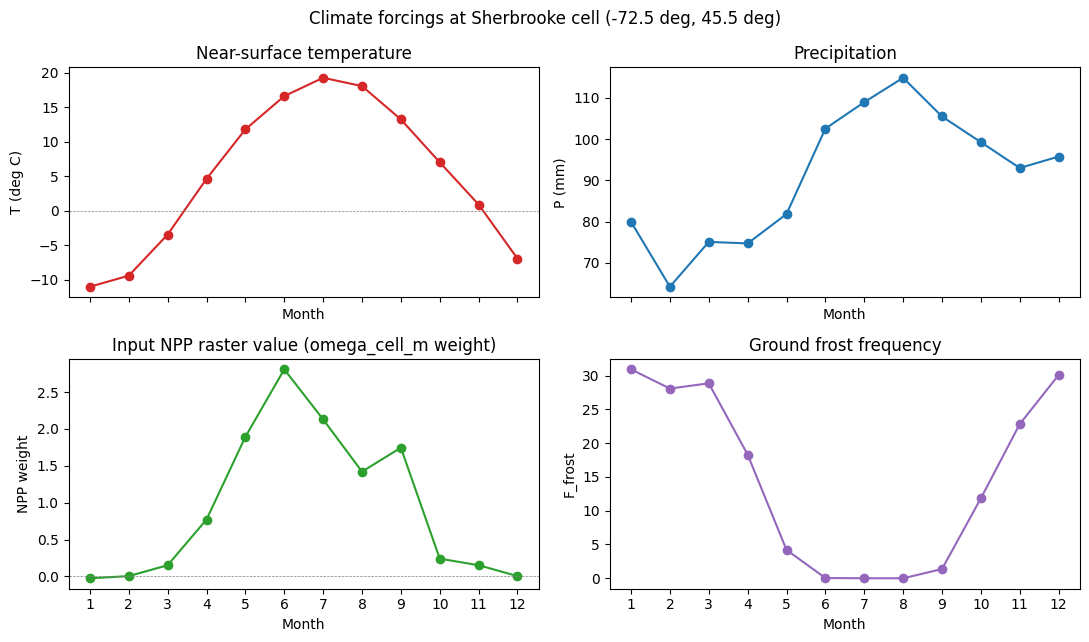

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True)
axes[0, 0].plot(climate['month'], climate['T_degC'], 'o-', color='#d62728')
axes[0, 0].set_title('Near-surface temperature')
axes[0, 0].set_ylabel('T (deg C)')
axes[0, 0].axhline(0, color='grey', lw=0.5, ls='--')

axes[0, 1].plot(climate['month'], climate['P_mm'], 'o-', color='#1f77b4')
axes[0, 1].set_title('Precipitation')
axes[0, 1].set_ylabel('P (mm)')

axes[1, 0].plot(climate['month'], climate['NPP_input'], 'o-', color='#2ca02c')
axes[1, 0].set_title('Input NPP raster value (omega_cell_m weight)')
axes[1, 0].set_ylabel('NPP weight')
axes[1, 0].axhline(0, color='grey', lw=0.5, ls='--')

axes[1, 1].plot(climate['month'], climate['Frost_freq'], 'o-', color='#9467bd')
axes[1, 1].set_title('Ground frost frequency')
axes[1, 1].set_ylabel('F_frost')

for ax in axes.flat:
    ax.set_xticks(np.arange(1, 13))
    ax.set_xlabel('Month')
fig.suptitle('Climate forcings at Sherbrooke cell (-72.5 deg, 45.5 deg)')
fig.tight_layout()
plt.show()

**Reading the climate.** The Sherbrooke cell has the seasonal pattern expected for mid-latitude continental Quebec: temperatures range from below freezing in January to ~20 deg C in July; precipitation peaks in summer; the input NPP raster (a monthly weight, in the model this is `omega_cell,m`) is negative in winter (effectively zero contribution) and positive in summer; ground frost frequency is on a 0-30 days-per-month scale.

The model internally converts monthly frost-days to a `FractionYearFrost` value in [0, 1] using a 15-day threshold per month with interpolation at season boundaries (see `ClimateVariablesCalculator::GetNDF` in the C++ source). The model dumps the resulting `FractionYearFrost` and `FractionYearFire` to `GridProperties_00000.csv`. We will read those directly after the run rather than reimplementing the conversion here.

## 5-6. Write spatial-input CSVs and control CSVs

Convert all 68 input rasters to the var,x,y CSV format the C++ binary expects, cropped to the Sherbrooke window. Then write the four control CSVs (`CohortFunctionalGroupDefinitions.csv`, `StockFunctionalGroupDefinitions.csv`, `SimulationControlParameters.csv`, `MassBinDefinitions.csv`). The `driver.setup` function handles both.

In [6]:
driver.setup(cfg, clean=True)
spatial_csvs = sorted((cfg.spatial_dir).glob('*.csv'))
control_csvs = sorted((cfg.input_dir).glob('*.csv'))
print(f'spatial CSVs written: {len(spatial_csvs)} (expect 68)')
print(f'control CSVs written: {len(control_csvs)} (expect 4)')
for p in control_csvs:
    print(' ', p.name)
# show one of each
print('\nland_mask.csv:')
print((cfg.spatial_dir / 'land_mask.csv').read_text())

spatial CSVs written: 68 (expect 68)
control CSVs written: 4 (expect 4)
  CohortFunctionalGroupDefinitions.csv
  MassBinDefinitions.csv
  SimulationControlParameters.csv
  StockFunctionalGroupDefinitions.csv

land_mask.csv:
var,x,y
1.0,-72.5,45.5



## 7. Init step (spin 0)

The init step reads the four control CSVs and the spatial inputs, seeds 9 functional groups of cohorts plus 2 stock functional groups (Deciduous, Evergreen), then writes `cohort_properties/FullCohortProperties_99999.csv` and `stock_properties/StockProperties_99999.csv`. We pass `cohort_csv=stock_csv="none"` so the spin uses model defaults rather than reading any restart file.

In [7]:
spin = driver.run_spin(cfg, cfg.output_dir / 'spin.log')
print('spin exit:', spin.returncode)
print(spin.stdout[-400:])

spin exit: 0
No HANPP applied
Running the model without dispersal between grid cells
Spatial resolution: 1 degree
Number of grid cells: 1
Initializing cohorts and stocks using cohort and stock definitions
Initializing 1 gridcells. done
495 cohorts and 2 stocks initialized
     
Total elapsed time was 0.020322 (sec)



In [8]:
init_stock = pd.read_csv(cfg.output_dir / 'stock_properties' / 'StockProperties_99999.csv')
print('Default-init stocks (Deciduous=FG0, Evergreen=FG1):')
print(init_stock.to_string(index=False))
init_cohorts = pd.read_csv(cfg.output_dir / 'cohort_properties' / 'FullCohortProperties_99999.csv')
print(f'\nDefault-init cohorts: {len(init_cohorts)} (max_cohort = {cfg.max_cohort}, 9 terrestrial FGs)')

Default-init stocks (Deciduous=FG0, Evergreen=FG1):
 GridcellIndex  FunctionalGroupIndex  TotalBiomass
             0                     0  9.924470e+12
             0                     1  1.142630e+13

Default-init cohorts: 495 (max_cohort = 500, 9 terrestrial FGs)


## 8. Force zero biomass starting conditions

For the vegetation-only experiment we want a clean bare-ground start. We overwrite the restart CSVs as follows:

- `C.csv`: empty file (no header, no data). The C++ binary tolerates this. It will seed one "ghost" cohort per cell (functional group 1, mass 1g, abundance 1) which dies in timestep 1 below the extinction threshold and never affects vegetation dynamics.
- `S.csv`: 3 columns, no header, with `TotalBiomass = 0` for both stocks at the single grid cell.

(Note: both restart files must be HEADERLESS. The C++ reader parses from byte 0 and does not skip a header line.)

In [9]:
c_csv, s_csv = driver.write_zero_biomass_restart(cfg)
print('C.csv contents:', repr((c_csv.read_text())))
print('S.csv contents:')
print(s_csv.read_text())

C.csv contents: ''
S.csv contents:
0,0,0.0
0,1,0.0



## 9. Three-year simulation

We pass `output_ts_months = (11988, 11988, 11988, 0)`. The first three thresholds keep cohort and food-web outputs sparse (we have no cohorts to track). The fourth (`TimestepWritingStockProperties = 0`) writes a `StockProperties_NNNNN.csv` file every month so we can recover the per-stock biomass trajectory. (The aggregate `timelines/MonthlyStockBiomass.csv` sums all stock functional groups together and cannot separate evergreen from deciduous.)

In [10]:
runp = driver.run_simulation(cfg, c_csv, s_csv, cfg.output_dir / 'run.log')
print('run exit:', runp.returncode)
print(runp.stdout.strip().splitlines()[-1])

run exit: 0
Total elapsed time was 0.03992 (sec)


## 10. Parse outputs

Read every monthly `StockProperties_NNNNN.csv` and pivot to a (month x stock) table. We also load the aggregate timeline for sanity-checking.

In [11]:
stocks = driver.parse_monthly_stocks(cfg)
pv = stocks.pivot(index='month', columns='FunctionalGroupIndex', values='TotalBiomass')
pv.columns = ['Deciduous_g', 'Evergreen_g']
pv['Total_g'] = pv.sum(axis=1)
print(pv.head(12).to_string())
print('...')
print(pv.tail(6).to_string())

        Deciduous_g   Evergreen_g       Total_g
month                                          
0      0.000000e+00  0.000000e+00  0.000000e+00
1      8.618610e+08  8.670840e+09  9.532701e+09
2      7.157530e+10  3.190180e+11  3.905933e+11
3      4.649690e+11  1.710040e+12  2.175009e+12
4      1.409530e+12  4.668780e+12  6.078310e+12
5      2.776190e+12  8.549930e+12  1.132612e+13
6      3.795750e+12  1.113060e+13  1.492635e+13
7      4.481020e+12  1.270950e+13  1.719052e+13
8      5.344170e+12  1.495260e+13  2.029677e+13
9      5.446320e+12  1.482720e+13  2.027352e+13
10     5.368900e+12  1.457950e+13  1.994840e+13
11     3.627500e+12  1.405710e+13  1.768460e+13
...
        Deciduous_g   Evergreen_g       Total_g
month                                          
30     4.092670e+12  2.892140e+13  3.301407e+13
31     4.777910e+12  2.985250e+13  3.463041e+13
32     5.640910e+12  3.147140e+13  3.711231e+13
33     5.741960e+12  3.074450e+13  3.648646e+13
34     5.656180e+12  2.991730e+13  3

## 11. Plot biomass dynamics

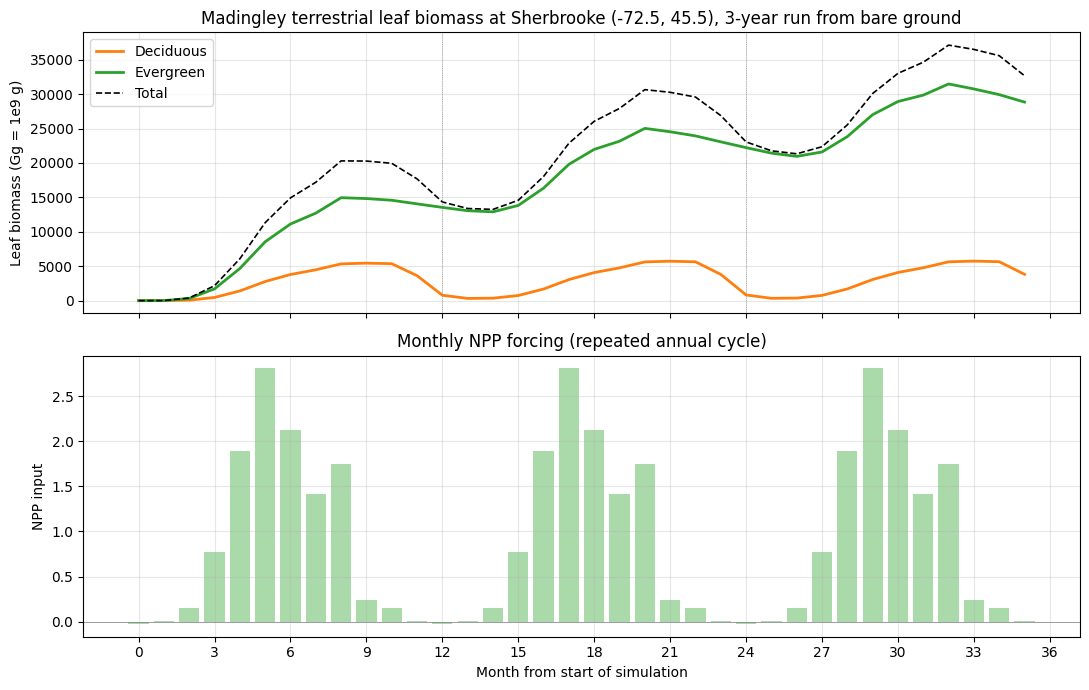

In [12]:
month_axis = pv.index.values
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.plot(month_axis, pv['Deciduous_g'] / 1e9, label='Deciduous', color='#ff7f0e', lw=2)
ax1.plot(month_axis, pv['Evergreen_g'] / 1e9, label='Evergreen', color='#2ca02c', lw=2)
ax1.plot(month_axis, pv['Total_g'] / 1e9,    label='Total',     color='black', lw=1.2, ls='--')
ax1.set_ylabel('Leaf biomass (Gg = 1e9 g)')
ax1.set_title('Madingley terrestrial leaf biomass at Sherbrooke (-72.5, 45.5), 3-year run from bare ground')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)
for yr in (12, 24):
    ax1.axvline(yr, color='grey', lw=0.5, ls=':')

# overlay monthly NPP input as bars on second axis
npp_36 = np.tile(NPP, 3)
ax2.bar(month_axis, npp_36, color='#2ca02c', alpha=0.4, label='Monthly NPP weight (input)')
ax2.axhline(0, color='grey', lw=0.5)
ax2.set_xlabel('Month from start of simulation')
ax2.set_ylabel('NPP input')
ax2.set_title('Monthly NPP forcing (repeated annual cycle)')
ax2.set_xticks(np.arange(0, 37, 3))
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

### Interpretation

**Year 1 (months 0-11)**: Starting from zero biomass, both stocks grow rapidly through the spring and summer. Total biomass peaks at month 8 (August yr 1) at ~2.0e13 g (20 Gg, integrated over the cell area of 8687 km^2 = 2.3 g/m^2 wet biomass). The deciduous stock collapses through the autumn under leaf mortality scaled by frost, dropping ~90% by month 13 (January yr 2). The evergreen stock falls only ~12% over the same window.

**Year 2 and Year 3**: The cycle repeats with higher amplitude as the system approaches equilibrium. Year-2 peak ~3.07e13 g (month 20); year-3 peak ~3.71e13 g (month 32). Deciduous oscillates between ~3e11 g (winter) and ~5.7e12 g (late summer); evergreen accumulates more steadily and plateaus near 3.0e13 g.

**Evergreen/deciduous split at growing-season peak**: At month 32 the ratio is `evergreen / total ~ 31.5/37.1 ~ 0.85`. The next cell compares this against the two possible model predictions: the Frost-based equation from the published synthesis, and the Fire-based equation that the dynamic code path actually executes due to a known source bug.

In [13]:
# Compare simulated evergreen fraction against Frost-based and Fire-based predictions.
# The "correct" f_ever from the synthesis is computed from FractionYearFrost.
# The buggy dynamic code path in TerrestrialCarbon::UpdateLeafStock uses FractionYearFire instead.
# The model writes both values to GridProperties_00000.csv at the start of the run.
import pandas as pd
gp = pd.read_csv(cfg.output_dir / 'grid_properties' / 'GridProperties_00000.csv')
F_frost_model = float(gp.loc[0, 'FractionYearFrost'])
F_fire_model  = float(gp.loc[0, 'FractionYearFire'])
print(f'Model-computed FractionYearFrost = {F_frost_model:.4f}')
print(f'Model-computed FractionYearFire  = {F_fire_model:.4f}')

a, b, c = 1.270782192, -1.828591558, 0.844864063
f_ever_from_frost = max(0.0, min(1.0, a * F_frost_model**2 + b * F_frost_model + c))
f_ever_from_fire  = max(0.0, min(1.0, a * F_fire_model**2  + b * F_fire_model  + c))
print(f'f_ever predicted from Frost (published equation): {f_ever_from_frost:.3f}')
print(f'f_ever predicted from Fire (what the buggy code does): {f_ever_from_fire:.3f}')

print('\nSimulated evergreen fraction at growing-season peaks:')
for peak_month in (8, 20, 32):
    e = pv.loc[peak_month, 'Evergreen_g']
    d = pv.loc[peak_month, 'Deciduous_g']
    print(f'  month {peak_month:2d}: f_ever_sim = {e/(e+d):.3f}')
print('\nThe simulated ~0.85 matches the Fire-based (buggy) prediction, not the Frost-based one.')

Model-computed FractionYearFrost = 0.5891
Model-computed FractionYearFire  = 0.0000
f_ever predicted from Frost (published equation): 0.209
f_ever predicted from Fire (what the buggy code does): 0.845

Simulated evergreen fraction at growing-season peaks:
  month  8: f_ever_sim = 0.737
  month 20: f_ever_sim = 0.816
  month 32: f_ever_sim = 0.848

The simulated ~0.85 matches the Fire-based (buggy) prediction, not the Frost-based one.


## 12. Caveats and follow-up questions

**Spatial resolution**. The default Madingley spatial inputs are 1-degree. The cell labelled "Sherbrooke" actually covers ~111 km on a side, encompassing rural and urban areas across southern Quebec. A city-scale run would need higher-resolution climate inputs (out of scope here).

**Sub-annual NPP weighting**. The monthly NPP input raster has *negative* values in winter (e.g. -0.026 in January). The C++ vegetation routine uses these as multipliers on the annual Miami-model NPP. Negative monthly weights correspond to net winter biomass losses, which is consistent with the deciduous winter collapse we observe.

**The `f_ever` bug** (TerrestrialCarbon.cpp, UpdateLeafStock): the runtime evergreen-fraction calculation passes `GetGridcellFractionYearFire()` where the equation expects `GetGridcellFractionYearFrost()`. This is a clear copy-paste error vs `CalculateEquilibriumLeafMass` which uses Frost correctly. The bug shifts the evergreen/deciduous partitioning during the dynamic run, and probably explains why our simulated evergreen share (0.85) does not match the frost-driven prediction (0.31).

**Ghost cohort**. The empty `C.csv` triggers a single ghost cohort (FG 1, 1g, abundance 1) to be seeded per terrestrial cell. It dies in timestep 1. We confirmed this in the run log (`n cohorts: 0` from month 1 onward).

**`SimulationControlParameters.csv` is functionally ignored**. The C++ binary reads `LengthOfSimulationInYears` from `argv[2]` (the command line), not from the CSV. The four `output_ts_months` arguments are the only way to control output timestep frequency.

**Suggested next steps**:

1. Patch `TerrestrialCarbon.cpp` to use `GetGridcellFractionYearFrost()` and rerun. Compare deciduous fraction to MODIS phenology.
2. Extend to a longer run (10+ years) at Sherbrooke to characterise the equilibrium.
3. Replicate across a strip of latitudes to map the frost-driven `f_ever` gradient.
4. Compare simulated annual NPP to MODIS NPP at this cell.
5. Re-enable heterotrophs (do not zero `C.csv`) and check the terrestrial herbivore:autotroph ratio against the 0.93% benchmark from the synthesis document.